# Mapa vectorial de obras por autor con embeddings de OpenAI

Este notebook genera embeddings de fragmentos con modelos de OpenAI, agrega vectores por obra y por autor, y produce varias visualizaciones para comprobar si las obras de un mismo autor aparecen próximas en el espacio de características.

Visualizaciones incluidas:

- PCA y UMAP de obras completas.
- UMAP de fragmentos.
- Heatmap de similitud coseno entre obras.
- Red de similitud entre obras.
- Métricas de cohesión por autor: vecinos del mismo autor, distancia intra/interautor, silhouette score.
- Tablas de vecinos más cercanos por obra.

UMAP/t-SNE sirven para una exploración visual. Para las conclusiones cuantitativas usaremos las métricas y similitudes calculadas en el espacio original de embeddings.

In [1]:
import os
import pickle
from pathlib import Path
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from openai import OpenAI

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

import umap
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx

from whodunit_stylometry.utils.data_utils import discover_corpus
from whodunit_stylometry.utils.embedding_utils import (
    get_encoding,
    chunk_text_by_tokens,
    text_hash,
    call_embeddings_api,
    weighted_average_embeddings,
    simple_average_embeddings,
    nearest_neighbors_table,
    pairwise_author_metrics,
    build_similarity_network,
)
from whodunit_stylometry.utils.plot_utils import (
    plot_work_length_distribution_by_author,
    add_projection,
    plot_projection,
)

load_dotenv()

True

## Configuración

In [2]:
CORPUS_DIR = Path("../corpus/normalized")
OUTPUT_DIR = Path("../artifacts/openai_embeddings")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL = "text-embedding-3-large"  # o "text-embedding-3-small"
EMBEDDING_DIMENSIONS = None  # por ejemplo: 1536, 1024, 512, o None (usa el nativo del modelo)

# Segmentación
CHUNK_TOKENS = 1200
CHUNK_OVERLAP = 150
MIN_CHUNK_TOKENS = 120

# Batching para llamadas a la API
BATCH_SIZE = 64
MAX_RETRIES = 6

# Caché de embeddings
CACHE_DIR = OUTPUT_DIR / "embedding_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = CACHE_DIR / f"cache_{MODEL}_{EMBEDDING_DIMENSIONS or 'native'}.pkl"

# Visualización
RANDOM_STATE = 42
N_NEIGHBORS_UMAP = 10
MIN_DIST_UMAP = 0.08
TOP_K_NETWORK_EDGES = 3  # número de vecinos por obra para la red
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
assert os.environ.get("OPENAI_API_KEY"), "Define OPENAI_API_KEY antes de continuar."

## Carga del corpus

In [3]:
works_df = discover_corpus(CORPUS_DIR)
print(f"Obras encontradas: {len(works_df)}")
print(f"Autores encontrados: {works_df['author'].nunique()}")
works_df[["author", "work", "word_count", "char_count", "path"]].head(10)

Obras encontradas: 95
Autores encontrados: 6


,author,work,word_count,char_count,path
0,anna_katharine_green,akg-7_to_12_a_detective_story,14817,80261,../corpus/normalized/anna_katharine_green/akg-...
1,anna_katharine_green,akg-a_difficult_problem,7988,42538,../corpus/normalized/anna_katharine_green/akg-...
2,anna_katharine_green,akg-a_matter_of_millions,108476,585362,../corpus/normalized/anna_katharine_green/akg-...
3,anna_katharine_green,akg-a_strange_disappearance,51811,275553,../corpus/normalized/anna_katharine_green/akg-...
4,anna_katharine_green,akg-agatha_webb,90205,484862,../corpus/normalized/anna_katharine_green/akg-...
5,anna_katharine_green,akg-behind_closed_doors,123475,662970,../corpus/normalized/anna_katharine_green/akg-...
6,anna_katharine_green,akg-cynthia_wakehams_money,81278,431620,../corpus/normalized/anna_katharine_green/akg-...
7,anna_katharine_green,akg-dark_hollow,92280,498959,../corpus/normalized/anna_katharine_green/akg-...
8,anna_katharine_green,akg-doctor_izard,49139,263375,../corpus/normalized/anna_katharine_green/akg-...
9,anna_katharine_green,akg-hand_and_ring,145581,795732,../corpus/normalized/anna_katharine_green/akg-...


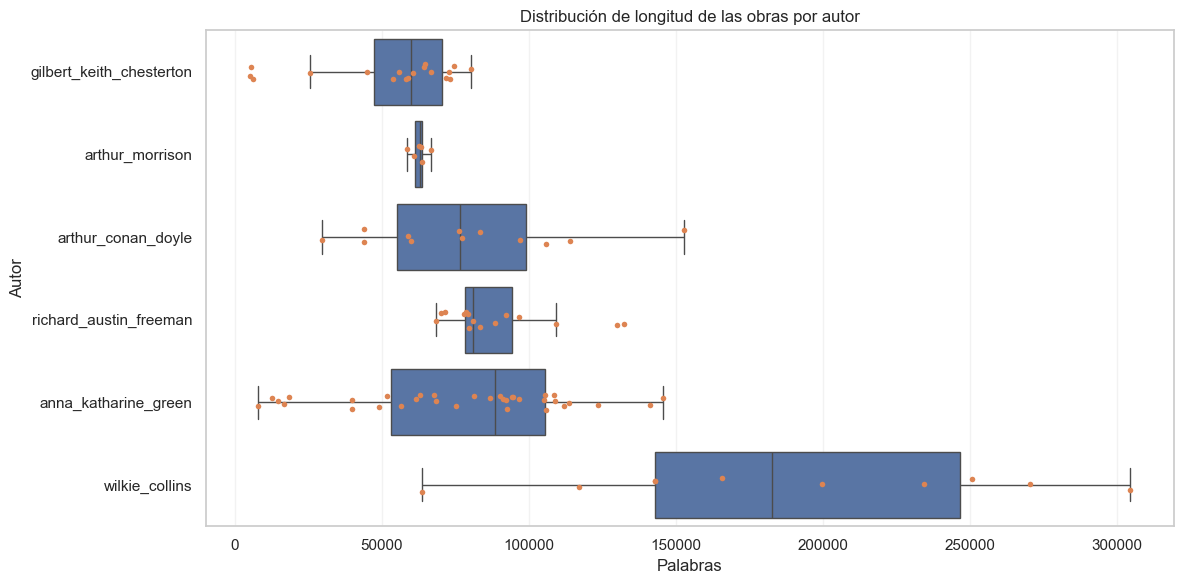

In [4]:
plot_work_length_distribution_by_author(works_df)

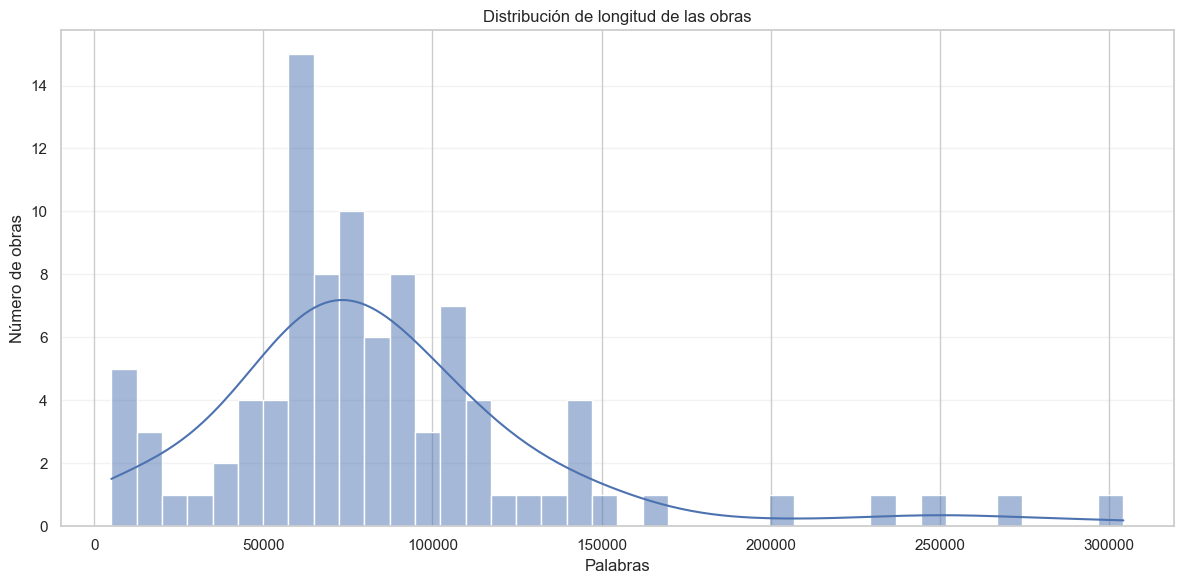

In [5]:
plt.figure(figsize=(12, 6))

sns.histplot(data=works_df, x="word_count", bins=40, kde=True)

plt.title("Distribución de longitud de las obras")
plt.xlabel("Palabras")
plt.ylabel("Número de obras")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Segmentación en fragmentos

Los embeddings tienen límite de contexto, por eso vamos a generar embeddings de fragmentos y después agregamos por obra.

In [6]:
encoding = get_encoding(MODEL)
print(f"Encodificación para {MODEL}: {encoding.name}, con vocabulario de {encoding.n_vocab} tokens.")

Encodificación para text-embedding-3-large: cl100k_base, con vocabulario de 100277 tokens.


In [7]:
chunk_rows = []

for work_id, row in tqdm(works_df.reset_index(drop=True).iterrows(), total=len(works_df), desc="Troceando obras"):
    chunks = chunk_text_by_tokens(row["text"], CHUNK_TOKENS, CHUNK_OVERLAP, MIN_CHUNK_TOKENS, encoding)
    for ch in chunks:
        chunk_rows.append(
            {
                "work_id": work_id,
                "author": row["author"],
                "work": row["work"],
                "filename": row["filename"],
                "path": row["path"],
                "chunk_index": ch["chunk_index"],
                "chunk_text": ch["text"],
                "token_count": ch["token_count"],
                "chunk_id": f"{work_id:05d}_{ch['chunk_index']:05d}",
            }
        )

chunks_df = pd.DataFrame(chunk_rows)
print(f"Fragmentos generados: {len(chunks_df)}")
chunks_df_agg = (
    chunks_df.groupby("author")
    .agg(works=("work", "nunique"), chunks=("chunk_id", "count"), tokens=("token_count", "sum"))
    .reset_index()
)
chunks_df_agg

Troceando obras:   0%|          | 0/95 [00:00<?, ?it/s]

Fragmentos generados: 9511


,author,works,chunks,tokens
0,anna_katharine_green,34,3039,3627926
1,arthur_conan_doyle,12,1105,1318343
2,arthur_morrison,6,451,539250
3,gilbert_keith_chesterton,18,1105,1315872
4,richard_austin_freeman,15,1586,1896535
5,wilkie_collins,10,2225,2663960


## Embeddings con caché

Para evitar pagar por cada ejecución, implementamos una caché local de embeddings. Si el texto, modelo y dimensiones no han cambiado, se recuperan los embeddings de la caché en lugar de llamar a la API.

In [8]:
if CACHE_PATH.exists():
    with open(CACHE_PATH, "rb") as f:
        embedding_cache = pickle.load(f)
else:
    embedding_cache = {}

print(f"Entradas en caché: {len(embedding_cache)}")

Entradas en caché: 9741


In [9]:
texts = chunks_df["chunk_text"].tolist()
hashes = [text_hash(t, MODEL, EMBEDDING_DIMENSIONS) for t in texts]
missing_indices = [i for i, h in enumerate(hashes) if h not in embedding_cache]
print(f"Embeddings faltantes: {len(missing_indices)} de {len(texts)}")

Embeddings faltantes: 0 de 9511


In [10]:
for start in tqdm(range(0, len(missing_indices), BATCH_SIZE), desc="Generando embeddings"):
    batch_indices = missing_indices[start : start + BATCH_SIZE]
    batch_texts = [texts[i] for i in batch_indices]
    vectors = call_embeddings_api(batch_texts, MODEL, EMBEDDING_DIMENSIONS, MAX_RETRIES, client)

    for i, vec in zip(batch_indices, vectors):
        embedding_cache[hashes[i]] = np.array(vec, dtype=np.float32)

    # guardar incrementalmente
    with open(CACHE_PATH, "wb") as f:
        pickle.dump(embedding_cache, f)

chunk_embeddings = np.vstack([embedding_cache[h] for h in hashes]).astype(np.float32)
chunk_embeddings = normalize(chunk_embeddings, norm="l2")
print(chunk_embeddings.shape)

Generando embeddings: 0it [00:00, ?it/s]

(9511, 3072)


## Agregación de embeddings por obra y autor

Para ello, se calcula el promedio ponderado por número de tokens. Se usa el promedio ponderado por número de tokens porque los fragmentos de una obra no siempre tienen la misma longitud, y un promedio simple daría el mismo peso a un fragmento largo que a uno muy corto, distorsionando el embedding final.

Al ponderar por tokens, cada fragmento contribuye de forma proporcional a la cantidad de texto que representa, por lo que el vector agregado refleja mejor el contenido total de la obra. Después se normaliza el vector resultante para que la similitud coseno sea estable.

In [11]:
# Agrupa todos los fragmentos que pertenecen a la misma obra
work_meta, work_embeddings = weighted_average_embeddings(
    chunks_df,
    chunk_embeddings,
    group_cols=["work_id", "author", "work", "filename", "path"],
)

# Agrupa todas las obras que pertenecen al mismo autor
author_meta, author_embeddings = simple_average_embeddings(
    work_meta,
    work_embeddings,
    group_cols=["author"],
)

print("Obras:", work_embeddings.shape)
print("Autores:", author_embeddings.shape)
work_meta.head()

Obras: (95, 3072)
Autores: (6, 3072)


,work_id,author,work,filename,path,n_chunks,token_count
0,0,anna_katharine_green,akg-7_to_12_a_detective_story,akg-7_to_12_a_detective_story.txt,../corpus/normalized/anna_katharine_green/akg-...,17,20324
1,1,anna_katharine_green,akg-a_difficult_problem,akg-a_difficult_problem.txt,../corpus/normalized/anna_katharine_green/akg-...,9,10596
2,2,anna_katharine_green,akg-a_matter_of_millions,akg-a_matter_of_millions.txt,../corpus/normalized/anna_katharine_green/akg-...,126,150714
3,3,anna_katharine_green,akg-a_strange_disappearance,akg-a_strange_disappearance.txt,../corpus/normalized/anna_katharine_green/akg-...,60,70914
4,4,anna_katharine_green,akg-agatha_webb,akg-agatha_webb.txt,../corpus/normalized/anna_katharine_green/akg-...,105,125032


En este bloque se construyen dos niveles de representación vectorial del corpus: primero, se obtiene un embedding por obra agrupando todos los fragmentos que pertenecen al mismo texto y calculando un promedio ponderado por número de tokens, de modo que los fragmentos más largos contribuyan proporcionalmente más al vector final de la obra.

Después, se obtiene un embedding por autor agrupando las obras de cada autor y calculando un promedio simple de sus embeddings, para que cada obra tenga el mismo peso y evitar que una obra muy extensa domine la representación del autor. Así se generan vectores comparables tanto a nivel de obra como a nivel de autor, que luego usaremos en visualizaciones, medidas de similitud o análisis de agrupamiento.

In [12]:
# Guardar matrices y metadatos para reutilizarlos
# posteriormente sin tener que recalcular todo
work_meta.to_csv(OUTPUT_DIR / "work_metadata.csv", index=False)
chunks_df.drop(columns=["chunk_text"]).to_csv(OUTPUT_DIR / "chunk_metadata.csv", index=False)
np.save(OUTPUT_DIR / "work_embeddings.npy", work_embeddings)
np.save(OUTPUT_DIR / "chunk_embeddings.npy", chunk_embeddings)
print(f"Guardado en: {OUTPUT_DIR.resolve()}")

Guardado en: /Users/elle/Library/Mobile Documents/com~apple~CloudDocs/Data Science/@UOC/Asignaturas/@TFG/whodunit-stylometry/artifacts/openai_embeddings


## Visualización de las obras en espacios de PCA, UMAP y t-SNE

PCA, UMAP y t-SNE son técnicas de reducción de dimensionalidad que permiten proyectar embeddings de muchas dimensiones en un espacio de 2 o 3 dimensiones para poder visualizarlos.

**PCA** es una técnica lineal que busca las direcciones de máxima varianza de los datos, por lo que es rápida, estable e interpretable, aunque puede perder relaciones complejas no lineales. Sirve como una referencia simple y robusta.

**UMAP** es una técnica no lineal que intenta conservar tanto la estructura local como parte de la estructura global del espacio original, por lo que suele funcionar muy bien para visualizar agrupamientos de textos u obras similares. Suele ser la opción principal para explorar embeddings.

In [13]:
# PCA
pca = PCA(n_components=3, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(work_embeddings)
work_proj = add_projection(work_meta, pca_coords, "pca")
print("Varianza explicada PCA:", pca.explained_variance_ratio_, "Total:", pca.explained_variance_ratio_.sum())

Varianza explicada PCA: [0.1840951  0.11166846 0.06638552] Total: 0.36214906


In [14]:
fig_pca_2 = plot_projection(work_proj, "pca_1", "pca_2", "PCA de obras completas en 2D")

In [15]:
fig_pca_3 = plot_projection(work_proj, x="pca_1", y="pca_2", z="pca_3", title="PCA de obras completas en 3D")

In [16]:
# UMAP
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=min(N_NEIGHBORS_UMAP, max(2, len(work_embeddings) - 1)),
    min_dist=MIN_DIST_UMAP,
    metric="cosine",
    random_state=RANDOM_STATE,
)
umap_coords = umap_model.fit_transform(work_embeddings)
work_proj = add_projection(work_proj, umap_coords, "umap")

/Users/elle/Library/Mobile Documents/com~apple~CloudDocs/Data Science/@UOC/Asignaturas/@TFG/whodunit-stylometry/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [17]:
fig_umap_2 = plot_projection(work_proj, "umap_1", "umap_2", "UMAP de obras completas en 2D")

In [18]:
fig_umap_3 = plot_projection(work_proj, x="umap_1", y="umap_2", z="umap_3", title="UMAP de obras completas en 3D")

## UMAP de fragmentos

En esta visualización, cada punto es un fragmento. Esto permite ver si los fragmentos de una misma obra forman una nube compacta o si están dispersos, lo que puede indicar variabilidad estilística dentro de la obra.

In [19]:
chunks_vis_df = chunks_df.reset_index(drop=True).copy()

chunk_umap = umap.UMAP(
    n_components=3,
    n_neighbors=min(15, max(2, len(chunk_embeddings) - 1)),
    min_dist=0.05,
    metric="cosine",
    random_state=RANDOM_STATE,
).fit_transform(chunk_embeddings)

chunks_vis_df["umap_1"] = chunk_umap[:, 0]
chunks_vis_df["umap_2"] = chunk_umap[:, 1]
chunks_vis_df["umap_3"] = chunk_umap[:, 2]

fig_chunks_2 = px.scatter(
    chunks_vis_df,
    x="umap_1",
    y="umap_2",
    color="author",
    hover_data=["author", "work", "chunk_index", "token_count"],
    title="UMAP de fragmentos en 2D",
    height=760,
)
fig_chunks_2.update_traces(marker=dict(size=6, opacity=0.55))
fig_chunks_2.show()

/Users/elle/Library/Mobile Documents/com~apple~CloudDocs/Data Science/@UOC/Asignaturas/@TFG/whodunit-stylometry/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [20]:
fig_chunks_3 = px.scatter_3d(
    chunks_vis_df,
    x="umap_1",
    y="umap_2",
    z="umap_3",
    color="author",
    hover_data=["author", "work", "chunk_index", "token_count"],
    title="UMAP de fragmentos en 3D",
    height=760,
)
fig_chunks_3.update_traces(marker=dict(size=6, opacity=0.40))
fig_chunks_3.show()

## Heatmap de similitud coseno entre obras y autores

Estas visualizaciones son más cuantitativas que UMAP porque se calcula directamente en el espacio original de embeddings.

In [21]:
# Similitud obra-obra
sim_matrix = cosine_similarity(work_embeddings)

sim_df = pd.DataFrame(sim_matrix, index=work_meta["work"], columns=work_meta["work"])
sim_df

work,akg-7_to_12_a_detective_story,akg-a_difficult_problem,akg-a_matter_of_millions,akg-a_strange_disappearance,akg-agatha_webb,akg-behind_closed_doors,akg-cynthia_wakehams_money,akg-dark_hollow,akg-doctor_izard,akg-hand_and_ring,...,wc-armadale,wc-basil,wc-man_and_wife,wc-no_name,wc-poor_miss_finch,wc-the_dead_secret,wc-the_haunted_hotel,wc-the_law_and_the_lady,wc-the_moonstone,wc-the_woman_in_white
work,,,,,,,,,,,,,,,,,,,,,
akg-7_to_12_a_detective_story,1.000000,0.781326,0.814625,0.853216,0.828473,0.832441,0.780543,0.799795,0.795402,0.803308,...,0.772742,0.783755,0.806854,0.782627,0.743526,0.781676,0.784480,0.806911,0.803089,0.778518
akg-a_difficult_problem,0.781326,1.000000,0.802184,0.847385,0.824799,0.846331,0.792240,0.806377,0.807494,0.817430,...,0.764433,0.784584,0.749060,0.737549,0.710132,0.752792,0.779829,0.821442,0.771297,0.769677
akg-a_matter_of_millions,0.814625,0.802184,1.000001,0.891008,0.856691,0.892344,0.859948,0.852572,0.842165,0.861165,...,0.813769,0.819240,0.834614,0.826701,0.811871,0.821639,0.848601,0.829542,0.788214,0.803708
akg-a_strange_disappearance,0.853216,0.847385,0.891008,1.000000,0.883612,0.902628,0.870262,0.877323,0.868378,0.862955,...,0.841418,0.849894,0.845824,0.849111,0.818124,0.841950,0.841220,0.868850,0.847077,0.834520
akg-agatha_webb,0.828473,0.824799,0.856691,0.883612,1.000000,0.880488,0.865514,0.895128,0.875277,0.886145,...,0.844431,0.831599,0.844180,0.840171,0.784764,0.844694,0.832956,0.843647,0.810963,0.803351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wc-the_dead_secret,0.781676,0.752792,0.821639,0.841950,0.844694,0.853328,0.867327,0.839909,0.859214,0.796525,...,0.872824,0.873446,0.882405,0.903279,0.848003,1.000000,0.876312,0.873203,0.857265,0.870539
wc-the_haunted_hotel,0.784480,0.779829,0.848601,0.841220,0.832956,0.862936,0.844241,0.810399,0.808227,0.804803,...,0.858899,0.857703,0.881956,0.881558,0.847121,0.876312,1.000001,0.871664,0.821205,0.887485
wc-the_law_and_the_lady,0.806911,0.821442,0.829542,0.868850,0.843647,0.881152,0.857100,0.848317,0.834905,0.839042,...,0.882805,0.893160,0.878627,0.873746,0.855411,0.873203,0.871664,1.000000,0.854171,0.890218


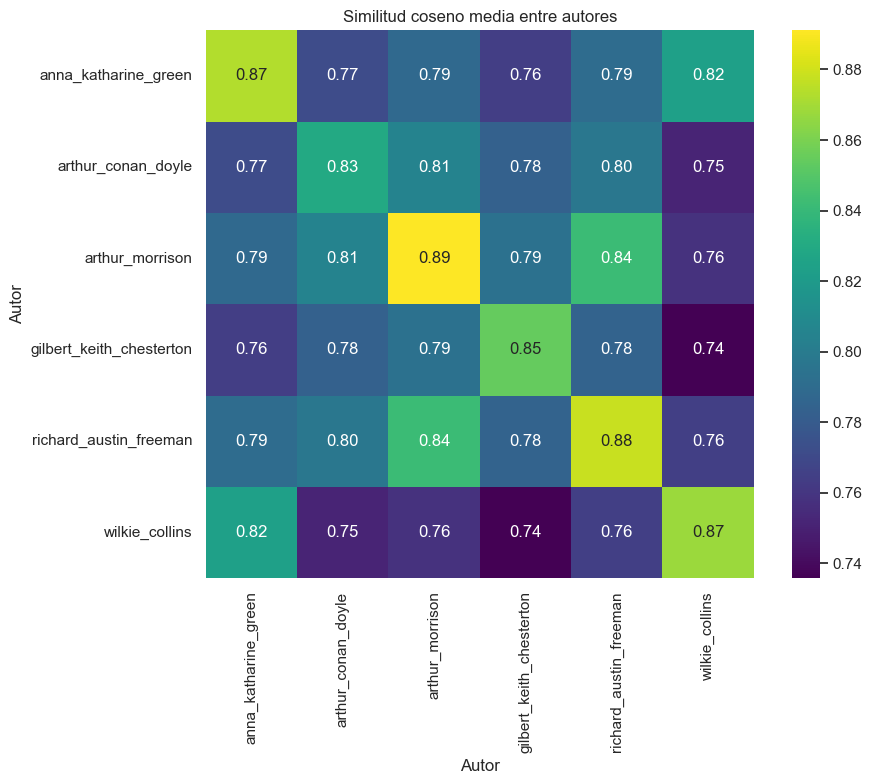

In [22]:
# Asociar cada obra con su autor
authors = work_meta["author"].values

# Similitud media autor-autor
author_sim = pd.DataFrame(
    index=sorted(work_meta["author"].unique()), columns=sorted(work_meta["author"].unique()), dtype=float
)

for a1 in author_sim.index:
    for a2 in author_sim.columns:
        idx1 = np.where(authors == a1)[0]
        idx2 = np.where(authors == a2)[0]

        vals = sim_matrix[np.ix_(idx1, idx2)]

        # Si es el mismo autor, quitamos la diagonal obra consigo misma
        if a1 == a2 and len(idx1) > 1:
            vals = vals[~np.eye(len(idx1), dtype=bool)]

        author_sim.loc[a1, a2] = vals.mean()

plt.figure(figsize=(10, 8))
sns.heatmap(author_sim.astype(float), cmap="viridis", annot=True, fmt=".2f", square=True)

plt.title("Similitud coseno media entre autores")
plt.xlabel("Autor")
plt.ylabel("Autor")
plt.tight_layout()
plt.show()

En este visualización, la diagonal de `author_sim` no representa “autor consigo mismo” como un único vector comparado consigo mismo, sino la similitud media entre las distintas obras de ese autor.

En esta parte:

```python
if a1 == a2 and len(idx1) > 1:
    vals = vals[~np.eye(len(idx1), dtype=bool)]
```

se elimina la diagonal interna, es decir, las comparaciones de cada obra consigo misma, que sí valen 1. Por tanto, para un mismo autor se promedian solo comparaciones como:

```text
obra 1 del autor vs obra 2 del autor
obra 1 del autor vs obra 3 del autor
obra 2 del autor vs obra 3 del autor
...
```

Por eso la diagonal puede ser, por ejemplo, 0.72, 0.81 o 0.64, no necesariamente 1. De hecho, eso es útil ya que mide la cohesión interna del autor. Cuanto más alta sea la diagonal, más parecidas son entre sí las obras de ese autor.

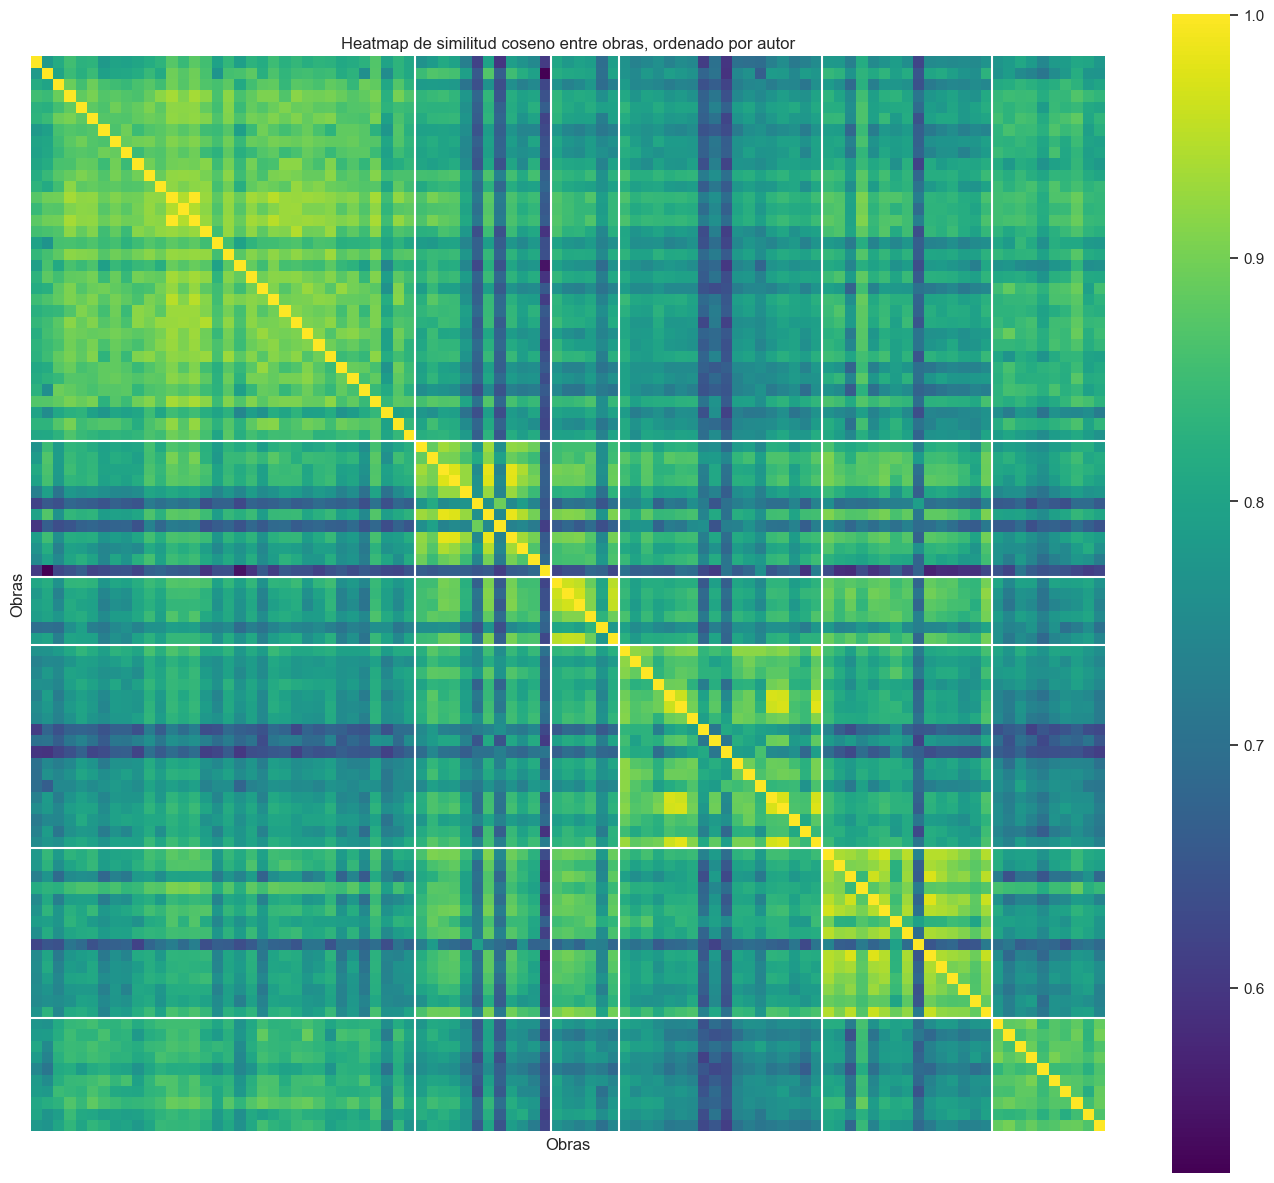

In [23]:
# Ordenar obras por autor
ordered_meta = work_meta.sort_values(["author", "work"]).reset_index(drop=True)
ordered_idx = ordered_meta.index.to_numpy()

ordered_embeddings = work_embeddings[ordered_idx]
sim_matrix_ordered = cosine_similarity(ordered_embeddings)

plt.figure(figsize=(14, 12))

sns.heatmap(sim_matrix_ordered, cmap="viridis", xticklabels=False, yticklabels=False, square=True)

plt.title("Heatmap de similitud coseno entre obras, ordenado por autor")
plt.xlabel("Obras")
plt.ylabel("Obras")

# Dibujar líneas separadoras entre autores
author_counts = ordered_meta["author"].value_counts(sort=False)
boundaries = author_counts.cumsum().values

for b in boundaries[:-1]:
    plt.axhline(b, color="white", linewidth=1.5)
    plt.axvline(b, color="white", linewidth=1.5)

plt.tight_layout()
plt.show()

En ese heatmap vemos bloques cuadrados más claros alrededor de la diagonal, delimitados por las líneas blancas, ya que las obras de un mismo autor son más parecidas entre sí que con las de otros autores. Como hemos ordenado las obras por author, todas las obras de cada autor quedan juntas, por tanto, cada bloque diagonal representa las comparaciones obra contra obra dentro del mismo autor.

Parece que el embedding captura bien la señal de estilo, ya que esos bloques muestran valores de similitud coseno más altos que las zonas fuera de la diagonal, que corresponden a comparaciones entre autores distintos. 

También es normal ver la diagonal principal muy intensa, porque cada obra comparada consigo misma tiene similitud 1. Lo importante no es esa línea, sino si hay cuadrados de alta similitud alrededor de ella dentro de cada autor.

## Vecinos más cercanos por obra

Esta tabla responde directamente a: “¿las obras más cercanas suelen ser del mismo autor?”.

In [24]:
nn_df = nearest_neighbors_table(work_meta.reset_index(drop=True), work_embeddings, top_k=6)
summary_same_author = nn_df.groupby("neighbor_rank")["same_author"].mean().reset_index()
summary_same_author["pct_same_author"] = 100 * summary_same_author["same_author"]

fig_nn = px.bar(
    summary_same_author,
    x="neighbor_rank",
    y="pct_same_author",
    title="Porcentaje de vecinos del mismo autor por rango de vecino más cercano",
    labels={"neighbor_rank": "Rango del vecino", "pct_same_author": "% mismo autor"},
    height=500,
)
fig_nn.update_yaxes(range=[0, 100])
fig_nn.show()

In [25]:
nn_df.head(30)

,work,author,neighbor_rank,neighbor_work,neighbor_author,same_author,cosine_similarity
0,akg-7_to_12_a_detective_story,anna_katharine_green,1,akg-room_number_3_and_other_detective_stories,anna_katharine_green,True,0.877267
1,akg-7_to_12_a_detective_story,anna_katharine_green,2,akg-masterpieces_of_mystery,anna_katharine_green,True,0.875186
2,akg-7_to_12_a_detective_story,anna_katharine_green,3,akg-the_woman_in_the_alcove,anna_katharine_green,True,0.871248
3,akg-7_to_12_a_detective_story,anna_katharine_green,4,akg-that_affair_next_door,anna_katharine_green,True,0.856532
4,akg-7_to_12_a_detective_story,anna_katharine_green,5,akg-a_strange_disappearance,anna_katharine_green,True,0.853216
5,akg-7_to_12_a_detective_story,anna_katharine_green,6,akg-the_golden_slipper_and_other_problems_for_...,anna_katharine_green,True,0.851049
6,akg-a_difficult_problem,anna_katharine_green,1,akg-masterpieces_of_mystery,anna_katharine_green,True,0.895192
7,akg-a_difficult_problem,anna_katharine_green,2,akg-room_number_3_and_other_detective_stories,anna_katharine_green,True,0.895175
8,akg-a_difficult_problem,anna_katharine_green,3,akg-the_filigree_ball,anna_katharine_green,True,0.879630
9,akg-a_difficult_problem,anna_katharine_green,4,akg-one_of_my_sons,anna_katharine_green,True,0.875137


In [ ]:
nn_df[not nn_df["same_author"]]

,work,author,neighbor_rank,neighbor_work,neighbor_author,same_author,cosine_similarity
11,akg-a_difficult_problem,anna_katharine_green,6,acd-the_memoirs_of_sherlock_holmes,arthur_conan_doyle,False,0.870620
211,acd-tales_of_terror_and_mystery,arthur_conan_doyle,2,raf-a_silent_witness,richard_austin_freeman,False,0.906671
212,acd-tales_of_terror_and_mystery,arthur_conan_doyle,3,akg-masterpieces_of_mystery,anna_katharine_green,False,0.902908
213,acd-tales_of_terror_and_mystery,arthur_conan_doyle,4,akg-room_number_3_and_other_detective_stories,anna_katharine_green,False,0.902419
236,acd-the_lost_world,arthur_conan_doyle,3,raf-the_golden_pool,richard_austin_freeman,False,0.788448
238,acd-the_lost_world,arthur_conan_doyle,5,gkc-the_club_of_queer_trades,gilbert_keith_chesterton,False,0.779852
248,acd-the_poison_belt,arthur_conan_doyle,3,gkc-manalive,gilbert_keith_chesterton,False,0.772916
249,acd-the_poison_belt,arthur_conan_doyle,4,gkc-the_club_of_queer_trades,gilbert_keith_chesterton,False,0.769462
250,acd-the_poison_belt,arthur_conan_doyle,5,gkc-the_poet_and_the_lunatics,gilbert_keith_chesterton,False,0.764394
270,acd-the_white_company,arthur_conan_doyle,1,gkc-the_return_of_don_quixote,gilbert_keith_chesterton,False,0.758595


## Métricas de cohesión por autor

Comparamos distancias intraautor frente a distancias interautor. Si el embedding captura una huella de estilo del autor, esperaríamos distancias intraautor menores que interautor.

In [27]:
pairs_df, author_metrics_df = pairwise_author_metrics(work_meta.reset_index(drop=True), work_embeddings)

fig_dist = px.box(
    pairs_df,
    x="same_author",
    y="cosine_distance",
    points="all",
    title="Distancias coseno intraautor vs. interautor",
    labels={"same_author": "Mismo autor", "cosine_distance": "Distancia coseno"},
    height=550,
)
fig_dist.show()

author_metrics_df

,author,n_works,mean_intra_author_distance,mean_inter_author_distance,separation_margin
2,arthur_morrison,6,0.108902,0.202767,0.093865
0,anna_katharine_green,34,0.126920,0.215956,0.089036
5,wilkie_collins,10,0.132092,0.220241,0.088149
4,richard_austin_freeman,15,0.122055,0.209470,0.087415
3,gilbert_keith_chesterton,18,0.145876,0.230371,0.084495
1,arthur_conan_doyle,12,0.170356,0.221267,0.050911


In [28]:
labels_author = work_meta["author"].astype("category").cat.codes.to_numpy()
sil = silhouette_score(work_embeddings, labels_author, metric="cosine")
print(f"Silhouette score por autor, métrica coseno: {sil:.4f}")
print(
    "Interpretación: >0 sugiere agrupamiento por autor; cerca de 0 indica solapamiento; <0 indica mezcla o mala separación."
)

Silhouette score por autor, métrica coseno: 0.2436
Interpretación: >0 sugiere agrupamiento por autor; cerca de 0 indica solapamiento; <0 indica mezcla o mala separación.


## Red de similitud entre obras

Cada obra se conecta con sus `TOP_K_NETWORK_EDGES` vecinos más cercanos. Las aristas intraautor se pueden inspeccionar con el campo `same_author`.

In [29]:
G = build_similarity_network(work_meta.reset_index(drop=True), work_embeddings, top_k=TOP_K_NETWORK_EDGES)
pos = nx.spring_layout(G, seed=RANDOM_STATE, weight="weight")

edge_x, edge_y = [], []
for u, v, data in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=0.8),
    hoverinfo="none",
    mode="lines",
    name="Similitud",
)

node_x, node_y, texts, authors = [], [], [], []
for node, data in G.nodes(data=True):
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    texts.append(data["label"])
    authors.append(data["author"])

node_df = pd.DataFrame({"x": node_x, "y": node_y, "label": texts, "author": authors})
node_trace = px.scatter(node_df, x="x", y="y", color="author", hover_name="label").data

fig_net = go.Figure(data=[edge_trace] + list(node_trace))
fig_net.update_layout(
    title=f"Red de similitud entre obras, top-{TOP_K_NETWORK_EDGES} vecinos por obra",
    showlegend=True,
    height=760,
    xaxis=dict(showgrid=False, zeroline=False, visible=False),
    yaxis=dict(showgrid=False, zeroline=False, visible=False),
)
fig_net.show()

## Exportación de resultados

Guardamos las tablas de vecinos y métricas.

In [30]:
work_proj.to_csv(OUTPUT_DIR / "work_projections.csv", index=False)
nn_df.to_csv(OUTPUT_DIR / "nearest_neighbors_by_work.csv", index=False)
pairs_df.to_csv(OUTPUT_DIR / "pairwise_work_distances.csv", index=False)
author_metrics_df.to_csv(OUTPUT_DIR / "author_cohesion_metrics.csv", index=False)

print("Archivos exportados:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print("-", p)

Archivos exportados:
- ../artifacts/openai_embeddings/author_cohesion_metrics.csv
- ../artifacts/openai_embeddings/chunk_embeddings.npy
- ../artifacts/openai_embeddings/chunk_metadata.csv
- ../artifacts/openai_embeddings/embedding_cache
- ../artifacts/openai_embeddings/nearest_neighbors_by_work.csv
- ../artifacts/openai_embeddings/pairwise_work_distances.csv
- ../artifacts/openai_embeddings/stylometric_features.csv
- ../artifacts/openai_embeddings/work_embeddings.npy
- ../artifacts/openai_embeddings/work_metadata.csv
- ../artifacts/openai_embeddings/work_projections.csv


##  Conclusiones sobre la proximidad de obras de un mismo autor

Para saber si “las obras de un mismo autor se pintan próximas” miraremos, en este orden:

1. `nearest_neighbors_by_work.csv`: si los vecinos top-1/top-3 suelen ser del mismo autor.
2. Boxplot intraautor vs interautor: la caja de `same_author=True` debería tener distancias menores.
3. `author_cohesion_metrics.csv`: `separation_margin > 0` indica que, para ese autor, sus obras están más cerca entre sí que de otros autores.
4. Silhouette score: positivo sugiere estructura por autor.
5. UMAP/PCA*: útil visualmente, pero no suficiente como prueba.